# Employment in AI, Data Science and Software Development (USA, May 2023)

**Module:** Data Visualisation and Communication – CA1

**Student:** Silmara Elisangela Souto – 2023357

**GitHub repository:** https://github.com/2023357/data-vis-ca1

**Video presentation:** 


## Introduction

Artificial Intelligence (AI) is one of the fastest-growing areas of the technology sector,
and it depends on professionals with skills in software development, data science and computer research.
This notebook uses data visualisation to explore employment in these fields in the United States.

The analysis uses the Occupational Employment and Wage Statistics (OEWS) dataset for May 2023, published by the U.S. Bureau of Labor Statistics (BLS). 
Because the BLS does not have a specific "AI" occupation category, this analysis selects a group of occupations closely related to AI,
such as Software Developers, Data Scientists and Computer and Information Research Scientists.

The notebook aims to answer the following questions:
1. Which AI-related occupations employ the most people?
2. How do wages compare across these occupations?
3. How do employment and wages vary across US states?
4. How has employment in AI-related occupations changed over time?

For each visualisation, the notebook explains the objective, why that type of chart was chosen, and what it reveals about AI employment.

## 1. Loading the Data.

In [1]:
# Import libraries for data handling and visualisation

# Load the BLS OEWS May 2023 dataset (this may take a few minutes)

# Display the first five rows to check the data loaded correctly


import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

oes_df = pd.read_excel("oesm23all/all_data_M_2023.xlsx")

oes_df.head()





,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,23.11,37.01,58.4,29050,35660,48060,76980,121470,NaN,NaN
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,56.19,81.29,111.36,54550,78330,116880,169090,231620,NaN,NaN
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,49.74,79.57,#,46400,66170,103460,165500,#,NaN,NaN
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN


In [2]:
# Check the number of rows and columns in the dataset
oes_df.shape

(413327, 32)

In [3]:
# Check the data type and number of non-null values in each column
oes_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413327 entries, 0 to 413326
Data columns (total 32 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   AREA          413327 non-null  int64 
 1   AREA_TITLE    413327 non-null  object
 2   AREA_TYPE     413327 non-null  int64 
 3   PRIM_STATE    413327 non-null  object
 4   NAICS         413327 non-null  object
 5   NAICS_TITLE   413327 non-null  object
 6   I_GROUP       413327 non-null  object
 7   OWN_CODE      413327 non-null  int64 
 8   OCC_CODE      413327 non-null  object
 9   OCC_TITLE     413327 non-null  object
 10  O_GROUP       413327 non-null  object
 11  TOT_EMP       413327 non-null  object
 12  EMP_PRSE      413327 non-null  object
 13  JOBS_1000     235826 non-null  object
 14  LOC_QUOTIENT  235826 non-null  object
 15  PCT_TOTAL     170470 non-null  object
 16  PCT_RPT       170470 non-null  object
 17  H_MEAN        413327 non-null  object
 18  A_MEAN        413327 non

## 2. Understanding the Data

The dataset comes from the U.S. Bureau of Labor Statistics (BLS) Occupational Employment and Wage Statistics (OEWS) survey and contains employment and wage estimates for May 2023. It has 413,327 rows and 32 columns.

Each row represents one occupation in a specific geographic area (the whole country, a state or a metropolitan area) and, in some cases, a specific industry. Because of this, the same occupation appears many times in the dataset, and the data must be filtered to the right level before it can be analysed.

The most relevant columns for this analysis are:
- `OCC_TITLE`: the name of the occupation
- `TOT_EMP`: the estimated number of people employed
- `A_MEAN` and `A_MEDIAN`: the mean and median annual wage (USD)
- `AREA_TITLE`: the geographic area

The `info()` output shows that numeric columns such as `TOT_EMP` and `A_MEAN` were loaded as `object` (text) instead of numbers. This happens because the BLS uses special symbols in place of some values: `*` and `**` when an estimate is not available, and `#` when a wage is above the highest value the BLS publishes. These columns therefore need to be cleaned and converted to numbers before any visualisation can be created.

Only three columns (`AREA`, `AREA_TYPE` and `OWN_CODE`) were loaded as integers. Some columns, such as `JOBS_1000` and `LOC_QUOTIENT`, also contain missing values, because they are only available for state and metropolitan area estimates.

## 3. Data Cleaning

In [4]:
# Count special symbols used by the BLS for unavailable or top-coded values
(oes_df['TOT_EMP'] == '**').sum()

np.int64(11598)

In [5]:

(oes_df['A_MEAN'] == '*').sum()


np.int64(5083)

In [6]:
(oes_df['A_MEAN'] == '#').sum()

np.int64(269)

In [7]:
# Convert employment and wage columns from text to numbers
# Values that cannot be converted (*, ** and #) become NaN

oes_df['TOT_EMP'] = oes_df['TOT_EMP'] = pd.to_numeric(oes_df['TOT_EMP'], errors="coerce")
oes_df['A_MEAN'] = pd.to_numeric(oes_df['A_MEAN'], errors="coerce")
oes_df['A_MEDIAN'] = pd.to_numeric(oes_df['A_MEDIAN'], errors="coerce")
oes_df['A_PCT10'] = pd.to_numeric(oes_df['A_PCT10'], errors="coerce")
oes_df['A_PCT25'] = pd.to_numeric(oes_df['A_PCT25'], errors="coerce")
oes_df['A_PCT75'] = pd.to_numeric(oes_df['A_PCT75'], errors="coerce")
oes_df['A_PCT90'] = pd.to_numeric(oes_df['A_PCT90'], errors="coerce")
oes_df['JOBS_1000'] = pd.to_numeric(oes_df['JOBS_1000'], errors="coerce")
oes_df['LOC_QUOTIENT'] = pd.to_numeric(oes_df['LOC_QUOTIENT'], errors="coerce")

In [8]:
# Confirm that the converted columns are now numeric 
oes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413327 entries, 0 to 413326
Data columns (total 32 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   AREA          413327 non-null  int64  
 1   AREA_TITLE    413327 non-null  object 
 2   AREA_TYPE     413327 non-null  int64  
 3   PRIM_STATE    413327 non-null  object 
 4   NAICS         413327 non-null  object 
 5   NAICS_TITLE   413327 non-null  object 
 6   I_GROUP       413327 non-null  object 
 7   OWN_CODE      413327 non-null  int64  
 8   OCC_CODE      413327 non-null  object 
 9   OCC_TITLE     413327 non-null  object 
 10  O_GROUP       413327 non-null  object 
 11  TOT_EMP       401729 non-null  float64
 12  EMP_PRSE      413327 non-null  object 
 13  JOBS_1000     232193 non-null  float64
 14  LOC_QUOTIENT  232193 non-null  float64
 15  PCT_TOTAL     170470 non-null  object 
 16  PCT_RPT       170470 non-null  object 
 17  H_MEAN        413327 non-null  object 
 18  A_ME

## Handling special symbols
As shown in the previous section, the numeric columns were loaded as text because the BLS uses special symbols in place of some values:
- `*` indicates that a wage estimate is not available
- `**` indicates that an employment estimate is not available
- `#` indicates a wage equal to or greater than $239,200 per year, the highest value the BLS publishes

For example, 11,598 rows of `TOT_EMP` contained `**`, and 5,083 rows of `A_MEAN` contained `*`.

The nine columns used in this analysis were converted to numbers using `pd.to_numeric` with `errors="coerce"`, which replaces any value that cannot be converted with `NaN` (missing value). After the conversion, the `info()` output shows these columns as `float64`.

**Handling the `#` values**

Unlike `*` and `**`, the `#` symbol does not represent missing data. It means the wage is top-coded: the real value exists but is higher than the maximum the BLS publishes ($239,200 per year). Three options were considered:

1. **Convert `#` to `NaN`** – simple and transparent, as no values are invented, but it slightly underestimates the highest wages.
2. **Replace `#` with $239,200** – keeps the information that the wage is high, but assigns a value that is likely lower than the real one.
3. **Remove the rows** – rejected, because it would also remove valid employment and wage values from the same rows.

Option 1 was chosen. A check of the AI-related occupations selected for this project showed that `#` does not appear in their mean or median wages, and appears only five times in the state-level 90th percentile wage (`A_PCT90`). Since the visualisations focus on mean and median wages, the impact of this decision on the analysis is minimal. Option 2 would be more appropriate in an analysis focused on the highest wages.



## 4. Selecting AI-related Occupations

In [9]:
# National-level estimates for all industries combined
national_df = oes_df.loc[(oes_df['AREA_TYPE'] == 1) & (oes_df['I_GROUP'] == 'cross-industry')]
national_df.shape

(1403, 32)

In [10]:
# Explore all Computer and Mathematical occupations (SOC group 15)
group15 = national_df.loc[national_df['OCC_CODE'].str.startswith('15-')]
group15[['OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'A_MEAN']]

,OCC_CODE,OCC_TITLE,O_GROUP,TOT_EMP,A_MEAN
132,15-0000,Computer and Mathematical Occupations,major,5177400.0,113140.0
133,15-1200,Computer Occupations,minor,4804840.0,113270.0
134,15-1210,Computer and Information Analysts,broad,674170.0,114420.0
135,15-1211,Computer Systems Analysts,detailed,498810.0,110800.0
136,15-1212,Information Security Analysts,detailed,175350.0,124740.0
137,15-1220,Computer and Information Research Scientists,broad,35210.0,157160.0
138,15-1221,Computer and Information Research Scientists,detailed,35210.0,157160.0
139,15-1230,Computer Support Specialists,broad,848420.0,66450.0
140,15-1231,Computer Network Support Specialists,detailed,158720.0,78640.0
141,15-1232,Computer User Support Specialists,detailed,689700.0,63640.0


In [21]:
# SOC codes of the occupations selected as AI-related
ai_codes = ['15-1252', '15-2051', '15-1221','15-1251','15-1253','15-1243','15-2041','15-2031']

# Keep only the AI-related occupations from the national data
ai_national = national_df.loc[national_df['OCC_CODE'].isin(ai_codes)].copy()
ai_national[['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEAN', 'A_MEDIAN']]

,OCC_CODE,OCC_TITLE,TOT_EMP,A_MEAN,A_MEDIAN
138,15-1221,Computer and Information Research Scientists,35210.0,157160.0,145080.0
145,15-1243,Database Architects,59920.0,137030.0,134700.0
148,15-1251,Computer Programmers,120370.0,107750.0,99700.0
149,15-1252,Software Developers,1656880.0,138110.0,132270.0
150,15-1253,Software Quality Assurance Analysts and Testers,203040.0,108460.0,101800.0
161,15-2031,Operations Research Analysts,117880.0,95600.0,83640.0
163,15-2041,Statisticians,29950.0,109190.0,104110.0
165,15-2051,Data Scientists,192710.0,119040.0,108020.0


In [23]:
# State-level estimates for all industries combined
states_df = oes_df.loc[(oes_df['AREA_TYPE'] == 2) & 
(oes_df['I_GROUP'] == 'cross-industry')]

# Keep only the AI-related occupations from the state data
ai_states= states_df.loc[states_df['OCC_CODE'].isin(ai_codes)].copy()
ai_states[['OCC_CODE', 'OCC_TITLE', 'TOT_EMP', 'A_MEAN', 'A_MEDIAN']]


,OCC_CODE,OCC_TITLE,TOT_EMP,A_MEAN,A_MEDIAN
181143,15-1221,Computer and Information Research Scientists,480.0,105360.0,102250.0
181144,15-1221,Computer and Information Research Scientists,360.0,147500.0,134910.0
181145,15-1221,Computer and Information Research Scientists,7560.0,187420.0,175530.0
181146,15-1221,Computer and Information Research Scientists,350.0,132070.0,126840.0
181147,15-1221,Computer and Information Research Scientists,50.0,126070.0,112580.0
...,...,...,...,...,...
181990,15-2051,Data Scientists,4810.0,139080.0,136490.0
181991,15-2051,Data Scientists,5640.0,148730.0,132620.0
181992,15-2051,Data Scientists,180.0,94330.0,67660.0
181993,15-2051,Data Scientists,3090.0,105250.0,101850.0


### Choosing the AI-related occupations

The BLS does not have a specific category for AI jobs. To build one, the national data was first filtered to show only the occupations in SOC group 15 (Computer and Mathematical Occupations). From this group, only the `detailed` occupations were considered, because the `major`, `minor` and `broad` levels are totals that combine several occupations and would count the same workers twice.

Each detailed occupation was then assessed with one question: does this job involve building, training or using AI models, data or software? Eight occupations were selected, covering the three areas in this project:

- **AI and Data Science:** Data Scientists, Computer and Information Research Scientists, Statisticians and Operations Research Analysts
- **Software Development:** Software Developers, Computer Programmers and Software Quality Assurance Analysts and Testers
- **Data infrastructure:** Database Architects

Occupations such as Computer User Support Specialists and Network Administrators were excluded, because they work with technology but are not directly involved in developing software, data or models.

This selection is a limitation of the analysis: the BLS data does not show how many workers in these occupations actually work on AI, and a different selection of occupations could lead to different results.

Two filtered datasets were created for the visualisations:
- `ai_national`: national data for the 8 occupations (8 rows)
- `ai_states`: state-level data for the 8 occupations (393 rows, since some occupations have no data in some states)

## 5. Visualisations


### 5.1 Horizontal Bar Chart – Employment by AI-related Occupation

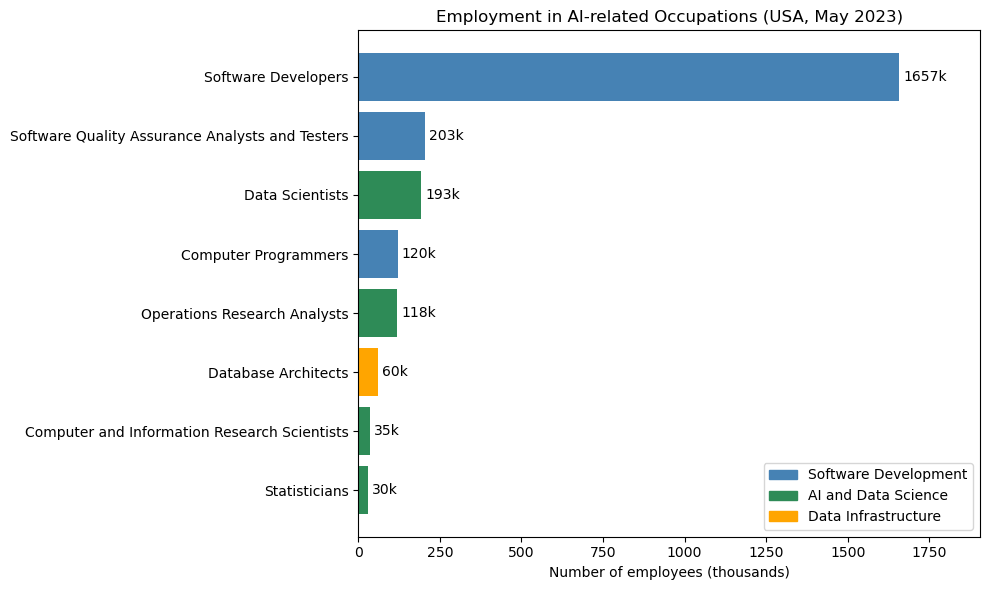

In [41]:
# Colour assigned to each area (also used in the pie chart)

from matplotlib.patches import Patch


color_map = {'Software Development': 'steelblue',
             'AI and Data Science': 'seagreen',
             'Data Infrastructure': 'orange'}

# Sort occupations by employment and give each bar the colour of its area
emp_sorted = ai_national.sort_values('TOT_EMP')
bar_colors = emp_sorted['AREA'].map(color_map)

# Horizontal bar chart of employment (in thousands) by occupation
plt.figure(figsize=(10, 6))
bars = plt.barh(emp_sorted['OCC_TITLE'], emp_sorted['TOT_EMP'] / 1000, color=bar_colors)
plt.bar_label(bars, fmt='%.0fk', padding=3)
plt.title("Employment in AI-related Occupations (USA, May 2023)")
plt.xlabel("Number of employees (thousands)")

# Extend the x-axis by 15% so the value labels are not cut off
plt.xlim(0, emp_sorted['TOT_EMP'].max() / 1000 * 1.15)

# Legend explaining the colours
handles = [Patch(color='steelblue', label='Software Development'),
           Patch(color='seagreen', label='AI and Data Science'),
           Patch(color='orange', label='Data Infrastructure')]
plt.legend(handles=handles)

plt.tight_layout()
plt.show()

- **Objective:** To compare how many people were employed in each AI-related occupation in the USA in May 2023, and identify which occupations employ the most workers.

- **Why this plot:** The data consists of one categorical variable (occupation) and one numerical variable (number of employees), which makes a bar chart the most suitable choice for comparing values across categories. Horizontal bars were chosen because the occupation names are long: in a vertical bar chart, the labels would overlap or need to be rotated, making them hard to read. The bars were sorted from largest to smallest so the ranking is clear at a glance.Each bar is coloured by field, and the exact number of employees is shown at the end of each bar, so values can be read without estimating from the axis.

- **Learning:** Software Developers dominate AI-related employment, with about 1.66 million workers. This represents around 69% of the 2.4 million people in the eight selected occupations, and is roughly eight times more than the second largest group, Software Quality Assurance Analysts and Testers (203,040). Data Scientists are the third largest group (192,710).

  In contrast, the more specialised occupations have much smaller workforces: Database Architects (59,920), Computer and Information Research Scientists (35,210) and Statisticians (29,950). Together, Data Scientists and Research Scientists, the roles most directly involved in developing AI models, account for only about 9% of the total. This suggests that most AI-related employment is in building and maintaining software, while AI specialists remain a much smaller group.

  The small size of these specialist groups could indicate that these skills are scarce. However, employment data alone cannot confirm a shortage, as it only counts people who are already employed and does not show how many positions remain unfilled.

### 5.2 Pie Chart – Share of AI-related Employment by Area

In [24]:
# Map each occupation code to one of three areas
area_map = {
    '15-2051': 'AI and Data Science',
    '15-1221': 'AI and Data Science',
    '15-2041': 'AI and Data Science',
    '15-2031': 'AI and Data Science',
    '15-1252': 'Software Development',
    '15-1251': 'Software Development',
    '15-1253': 'Software Development',
    '15-1243': 'Data Infrastructure'
}
ai_national['AREA'] = ai_national['OCC_CODE'].map(area_map)
ai_national[['OCC_TITLE', 'AREA']]


,OCC_TITLE,AREA
138,Computer and Information Research Scientists,AI and Data Science
145,Database Architects,Data Infrastructure
148,Computer Programmers,Software Development
149,Software Developers,Software Development
150,Software Quality Assurance Analysts and Testers,Software Development
161,Operations Research Analysts,AI and Data Science
163,Statisticians,AI and Data Science
165,Data Scientists,AI and Data Science


In [26]:
# Total employment in each area
area_emp = ai_national.groupby("AREA")["TOT_EMP"].sum()
area_emp

AREA
AI and Data Science      375750.0
Data Infrastructure       59920.0
Software Development    1980290.0
Name: TOT_EMP, dtype: float64

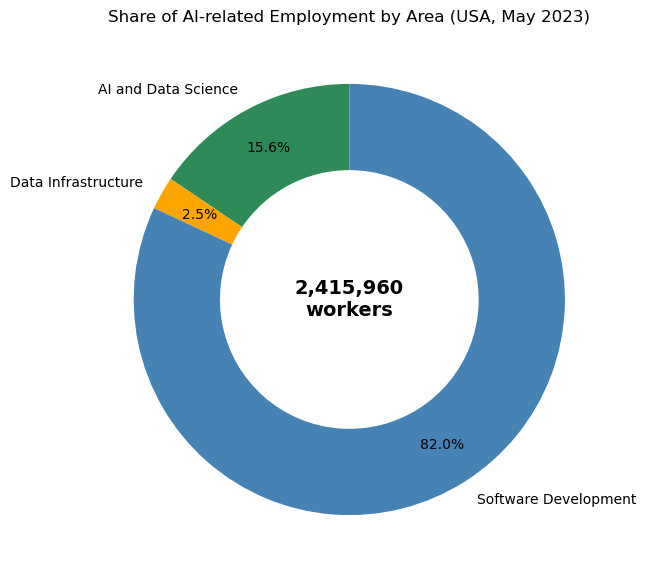

In [42]:
# Same colours as the bar chart, so each field has one colour across both charts
pie_colors = area_emp.index.map(color_map)

# Total number of employees, shown in the centre of the donut
total_emp = area_emp.sum()

# Donut chart of employment share by field
plt.figure(figsize=(7, 7))
plt.pie(area_emp, labels=area_emp.index, autopct="%1.1f%%", startangle=90,
        colors=pie_colors, wedgeprops={'width': 0.4}, pctdistance=0.8)
plt.text(0, 0, f"{total_emp:,.0f}\nworkers", ha='center', va='center',
         fontsize=14, fontweight='bold')
plt.title("Share of AI-related Employment by Area (USA, May 2023)")
plt.show()

- **Objective:** To show what proportion of AI-related employment belongs to each area (AI and Data Science, Software Development and Data Infrastructure), complementing the previous chart, which compared individual occupations.

- **Why this plot:** A donut chart, a variation of the pie chart, is suitable for showing part-to-whole relationships, where each slice represents a share of a total. The eight occupations were grouped into the three areas defined in Section 4, because a chart with eight slices would include several very small slices (for example, Statisticians represent only about 1.2% of the total) that would be difficult to read. Since the human eye is not precise at comparing angles, the percentage of each slice was added as a label. The donut format leaves space in the centre to display the total number of employees, and the same colours as the previous chart were kept so that each field is easy to recognise across both visualisations.

- **Learning:** Software Development accounts for 82.0% of AI-related employment, while AI and Data Science represents only 15.6% and Data Infrastructure 2.5%. In other words, roughly five out of every six workers in these occupations work in software development. This confirms the conclusion of the previous chart from a different perspective: the AI workforce is mainly made up of people who build and maintain software, while the specialists in data and AI models form a much smaller share.

  Grouping does not change the total number of employees (2.4 million), but the size of each slice depends on how the occupations were assigned to each area. For example, if Operations Research Analysts were not included in AI and Data Science, the share of this area would fall to about 10.7%.